# Importing the requirement


In [26]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import zipfile
import random

# Getting the dataset

In [2]:
dataset_path="cats_and_dogs_filtered (1).zip"
extract_path="cats_and_dogs"

# Extract the dataset

In [3]:
if not os.path.exists(extract_path):
    print("Extracting the dataset....")
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction Complete")

In [4]:
train_dir=os.path.join(extract_path,"cats_and_dogs_filtered/train/")
val_dir=os.path.join(extract_path,"cats_and_dogs_filtered/validation/")

In [5]:
print(train_dir)

cats_and_dogs\cats_and_dogs_filtered/train/


In [6]:
from PIL import Image
cat_dir=os.path.join(train_dir,"cats")

In [7]:
cat_dir

'cats_and_dogs\\cats_and_dogs_filtered/train/cats'

In [8]:
image_files=os.listdir(cat_dir)

In [9]:
print("available images:", image_files[:5])

available images: ['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.101.jpg']


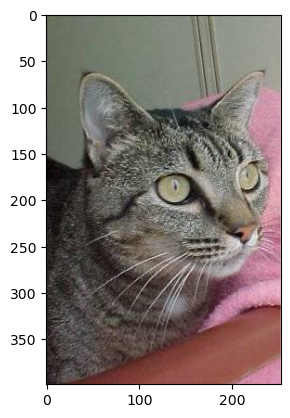

In [10]:
image_path=os.path.join(cat_dir,image_files[7])
image=Image.open(image_path)
plt.imshow(image)

In [11]:
# Preprocess image

train_datagen=ImageDataGenerator(rescale=1./255,rotation_range=20,horizontal_flip=True)
val_datagen=ImageDataGenerator(rescale=1./255)

In [12]:
train_generator=train_datagen.flow_from_directory(train_dir,
                                                  target_size=(150,150),
                                                  batch_size=32,
                                                  class_mode="binary")

Found 2000 images belonging to 2 classes.


In [13]:
val_generator=val_datagen.flow_from_directory(val_dir,
                                                  target_size=(150,150),
                                                  batch_size=32,
                                                  class_mode="binary")

Found 1000 images belonging to 2 classes.


In [14]:
# Build CNN Model

In [14]:
import keras

In [15]:
model=keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(512,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid') #binary classification
])
    

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
from keras.callbacks import EarlyStopping

In [17]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
history=model.fit(train_generator,epochs=20,validation_data=val_generator)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 454ms/step - accuracy: 0.7595 - loss: 0.4885 - val_accuracy: 0.7450 - val_loss: 0.5542
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 452ms/step - accuracy: 0.7760 - loss: 0.4758 - val_accuracy: 0.7060 - val_loss: 0.5688
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 458ms/step - accuracy: 0.7750 - loss: 0.4554 - val_accuracy: 0.7450 - val_loss: 0.5551
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 454ms/step - accuracy: 0.8120 - loss: 0.4088 - val_accuracy: 0.7340 - val_loss: 0.5708
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 462ms/step - accuracy: 0.8035 - loss: 0.4257 - val_accuracy: 0.7220 - val_loss: 0.6125
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 458ms/step - accuracy: 0.8320 - loss: 0.3827 - val_accuracy: 0.7500 - val_loss: 0.5809
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 471ms/step - accuracy: 0.8485 - loss: 0.3475 - val_accuracy: 0.7320 - val_loss: 0.6507
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 494ms/step - accuracy: 0.8515 - loss: 0.3372 - val_accu

# save the model

In [27]:
model.save("cat_dog_classifier.h5")
print("Model saved successfully")

Model saved successfully


In [28]:
loss,accuracy=model.evaluate(val_generator)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.7590 - loss: 0.9168


In [29]:
print(f' validation Accuracy :{accuracy *100:2f}%')

 validation Accuracy :75.900000%
